# 【notebook｜N-09】tiny 预训练复刻（对照 AlphaProof）
> 对应：《02-预训练/01-预训练原理.md》【文档｜DOC-PT】；代码 `F-b02-pretrain`

本 notebook 在自己造的"数学/Lean 风格"小语料上，从零训练一个 tiny GPT，观察 **loss 下降**
并生成文本。它在 CPU 上几十秒就能跑完，Colab 上更快。

**依赖**：`torch`（必需）、`matplotlib`（可选，用于画 loss 曲线）。无网络也可运行。
运行方式：Colab 直接 `Run all`；本地 `jupyter nbconvert --to notebook --execute --inplace N09_tiny预训练复刻.ipynb`。

**对照**：AlphaProof 的 nanoproof `pretrain.py`（Nemotron-CC-Math ~20B token，DDP +
MuonAdamW）与 `midtrain.py`（Lean-GitHub ~65M token）。本 notebook 是其"缩小 10^6 倍"的
可复刻版本：同样的 teacher forcing、交叉熵、课程/配比思想；优化器简化为 AdamW。


In [1]:
# 【N-09.c1】
import math, random, time
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)
random.seed(1337)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)


device = cuda


## 1. 自造语料（多域配比）

AlphaProof 预训练混合网页数学与 Lean 代码。这里用**模板语法**生成足够多、又足够结构化的
证明文本；组合够多，loss 会稳定下降。

In [2]:
# 【N-09.c2】
NAT = ["add_comm", "mul_comm", "add_assoc", "mul_assoc", "zero_add", "mul_one", "dvd_refl"]
LST = ["append_nil", "length_append", "map_map", "reverse_reverse"]

def build_corpus(n_blocks=400, seed=0):
    rng = random.Random(seed)
    out = []
    for i in range(n_blocks):
        if i % 2 == 0:
            out.append(f"theorem {rng.choice(NAT)}_{i} (a b c : Nat) : a + b + c = c + b + a := by")
            out.append("  induction a with")
            out.append("  | zero => simp")
            out.append("  | succ a ih => rw [Nat.succ_add, Nat.add_succ, ih]")
        else:
            out.append(f"theorem {rng.choice(LST)}_{i} (xs ys : List α) : xs ++ ys = xs ++ ys := by")
            out.append("  induction xs with")
            out.append("  | nil => simp")
            out.append("  | cons x xs ih => simp [ih]")
        out.append("")
    return "\n".join(out) + "\n"

text = build_corpus(400)
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s if c in stoi]
decode = lambda ids: "".join(itos[int(i)] for i in ids)
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
block_size = 128
print(f"语料 {len(text)} 字符, vocab {len(chars)}, train {len(train_data)}, val {len(val_data)}")

def get_batch(split, batch_size=32):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+1+block_size] for i in ix])
    return x.to(device), y.to(device)


语料 58140 字符, vocab 50, train 52326, val 5814


## 2. tiny GPT（内联，便于 Colab 独立运行）

结构：token embedding + 位置 embedding + 若干 Pre-LN Transformer block（因果自注意力 +
MLP）+ 输出投影。权重共享（`lm_head.weight = tok_emb.weight`）。约 0.6M 参数。
接口与 `01-基础/code/from_scratch/model.py` 的 `GPT` 一致：`forward(idx, targets)` 返回
`(logits, loss)`，`generate(idx, max_new_tokens)` 自回归采样。

In [3]:
# 【N-09.c3】
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.attn = nn.MultiheadAttention(n_embd, n_head, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4*n_embd), nn.GELU(), nn.Linear(4*n_embd, n_embd))
    def forward(self, x):
        T = x.size(1)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        a, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), attn_mask=mask, need_weights=False)
        x = x + a
        return x + self.mlp(self.ln2(x))

class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layer=4, n_head=4, n_embd=128):
        super().__init__()
        self.block_size, self.n_embd = block_size, n_embd
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(lambda m: nn.init.normal_(m.weight, std=0.02) if isinstance(m, (nn.Linear, nn.Embedding)) else None)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))[None]
        for b in self.blocks:
            x = b(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-100)
        return logits, loss
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=20):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-6)
            if top_k:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

model = GPT(len(chars), block_size).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"参数量 {n_params/1e6:.3f}M, 初始 loss 应约为 ln(vocab)= {math.log(len(chars)):.3f}")


参数量 0.816M, 初始 loss 应约为 ln(vocab)= 3.912


## 3. 训练循环

目标是最小化 next-token 交叉熵 $\mathcal{L}=-\frac{1}{T}\sum_t \log p_\theta(x_t\mid x_{<t})$。
这里用 AdamW + warmup/余弦；真实 nanoproof 用 MuonAdamW + DDP + 梯度累积。

In [4]:
# 【N-09.c4】
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
max_iters, warmup, min_lr = 300, 20, 3e-4
losses, eval_iters = [], 10

def lr_at(it):
    if it < warmup:
        return 3e-3 * (it + 1) / warmup
    p = min(1.0, (it - warmup) / (max_iters - warmup))
    return min_lr + 0.5 * (1 + math.cos(math.pi * p)) * (3e-3 - min_lr)

@torch.no_grad()
def estimate():
    model.eval()
    L = [model(*get_batch("val"))[1].item() for _ in range(eval_iters)]
    model.train()
    return sum(L) / len(L)

model.train()
t0 = time.time()
for it in range(max_iters):
    for g in optimizer.param_groups:
        g["lr"] = lr_at(it)
    x, y = get_batch("train")
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if it % 50 == 0 or it == max_iters - 1:
        losses.append(loss.item())
        print(f"iter {it:4d} | loss {loss.item():.4f} | ppl {math.exp(min(loss.item(),20)):.2f}")
val = estimate()
print(f"用时 {time.time()-t0:.1f}s | 最终 val_loss {val:.4f} | val_ppl {math.exp(min(val,20)):.2f}")


iter    0 | loss 4.0246 | ppl 55.96


iter   50 | loss 1.1345 | ppl 3.11


iter  100 | loss 0.3205 | ppl 1.38


iter  150 | loss 0.1496 | ppl 1.16


iter  200 | loss 0.0974 | ppl 1.10


iter  250 | loss 0.0906 | ppl 1.09


iter  299 | loss 0.0851 | ppl 1.09
用时 5.3s | 最终 val_loss 0.0866 | val_ppl 1.09


## 4. 采样：模型学会了什么

喂一个 `theorem ` 前缀，看模型续写。训练充分时它会拼出 `theorem ... := by` 与
`induction ... simp` 等结构。

In [5]:
# 【N-09.c5】
prompt = "theorem "
ids = torch.tensor([encode(prompt)], device=device)
out = model.generate(ids, max_new_tokens=160, temperature=0.8, top_k=20)
print(decode(out[0].tolist()))


theorem mul_assoc_211 (a b c : Nat) : a + b + c = c + b + a := by
  induction a with
  | zero => simp
  | succ a ih => rw [Nat.succ_add, Nat.add_succ, ih]

theorem map_


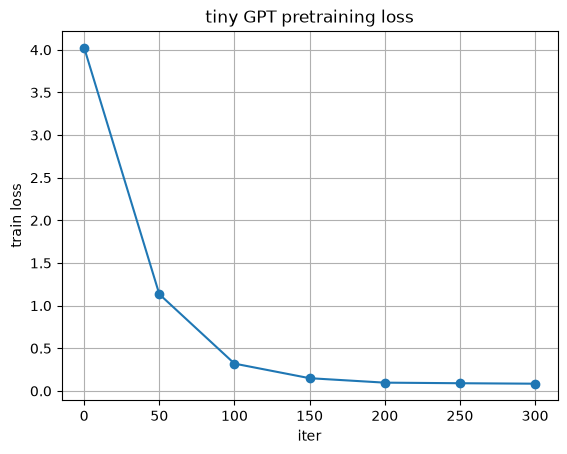

In [6]:
# 【N-09.c6】
try:
    import matplotlib.pyplot as plt
    plt.plot([i*50 for i in range(len(losses))], losses, marker="o")
    plt.xlabel("iter"); plt.ylabel("train loss"); plt.title("tiny GPT pretraining loss")
    plt.grid(True); plt.show()
except Exception as e:
    print("matplotlib 不可用，loss 序列：", losses)


## 5. 对照 AlphaProof 预训练设定

| 维度 | 本 notebook | nanoproof `pretrain.py` / `midtrain.py` |
|---|---|---|
| 语料 | 合成模板（几 KB） | Nemotron-CC-Math ~20B token + Lean-GitHub ~65M token |
| 目标 | next-token 交叉熵（teacher forcing） | 同 |
| 模型 | 0.6M 参数 GPT | ~数百 M 参数，GQA/滑窗/RoPE |
| 优化器 | AdamW | MuonAdamW（`optim.py`） |
| 并行 | 单卡/CPU | DDP + 梯度累积，可选 FP8 |
| 预算 | 300 步 | 由 `target_flops` 反推 iteration |

**核心不变量**：无论规模，损失都是
$\mathcal{L}=-\frac{1}{T}\sum_t \log p_\theta(x_t\mid x_{<t})$，梯度对 logits 是
`softmax(z) - onehot(y)`，困惑度 $\mathrm{ppl}=\exp(\mathcal{L})$ 起步约等于词表大小。

练习：
1. 把 `block_size` 加倍、`n_layer` 加大，观察 loss 与参数量；
2. 把语料减少到 50 个 block，观察过拟合（val loss 抬头）；
3. 关闭权重共享（去掉 `lm_head.weight = tok_emb.weight`），比较参数量。
